# Analysis of myths

In [1]:
import pandas as pd

myth_path = '../../data/tables/myths.csv'
df = pd.read_csv(myth_path)

df.head()

,run_id,condition_group,condition,model,replicate_id,num_agents,round,agent_id,myth_text,n_chars,n_words,source_json
0,sonnet45_directive_normative_r10_n5_005_neutra...,2agent_clean_sonnet45,myth_game_directive,anthropic/claude-sonnet-4.5,0,2,1,Agent_1,# The Myth of the Spring and the River\n\nIn t...,1255,208,data/json/sonnet45_directive_normative_r10_n5/...
1,sonnet45_directive_normative_r10_n5_005_neutra...,2agent_clean_sonnet45,myth_game_directive,anthropic/claude-sonnet-4.5,0,2,1,Agent_2,# The Tale of the Twin Rivers\n\nIn ancient ti...,1180,200,data/json/sonnet45_directive_normative_r10_n5/...
2,sonnet45_directive_normative_r10_n5_005_neutra...,2agent_clean_sonnet45,myth_game_directive,anthropic/claude-sonnet-4.5,0,2,2,Agent_2,"Myth: In the time before memory, the Sun and t...",1244,203,data/json/sonnet45_directive_normative_r10_n5/...
3,sonnet45_directive_normative_r10_n5_005_neutra...,2agent_clean_sonnet45,myth_game_directive,anthropic/claude-sonnet-4.5,0,2,2,Agent_1,"Myth: In the time before time, the Moon held a...",1247,205,data/json/sonnet45_directive_normative_r10_n5/...
4,sonnet45_directive_normative_r10_n5_005_neutra...,2agent_clean_sonnet45,myth_game_directive,anthropic/claude-sonnet-4.5,0,2,3,Agent_1,"Myth: Long ago, two Mountains stood across a g...",1373,218,data/json/sonnet45_directive_normative_r10_n5/...


### Set up and test judge

In [6]:
import os
from judge import LLMJudge

# Set API key directly — kernel env is separate from shell exports
# Avoid committing this file with the key present


rubric_path = '../../data/rubrics/moral_rubric.txt'
with open(rubric_path, 'r') as file:
    rubric = file.read()

judge = LLMJudge(
    prompt = rubric
    # model="google/gemma-4-31B-it"
    # ,model = "Qwen/Qwen3.5-9B"
    # ,model="MiniMaxAI/MiniMax-M3"
    ,model="openai/gpt-oss-20b"
)

# result = judge.evaluate("Agent A cooperated consistently across the exchange.")
# print(result.judgment)

# results = judge.evaluate_many(["first text", "second text"], batch_size=2, max_workers=2)

## Load and aggregate game details

In [60]:
# we define some runs of interest - this is a subset, this will need to be run for other runs as well 
runs_of_interest = ['sonnet45_directive_normative_r10_n5_005_neutral_rep00_myth_game_directive_anything',
 'sonnet45_directive_normative_r10_n5_006_neutral_rep01_myth_game_directive_anything',
 'sonnet45_directive_normative_r10_n5_007_neutral_rep02_myth_game_directive_anything',
 'sonnet45_directive_normative_r10_n5_008_neutral_rep03_myth_game_directive_anything',
 'sonnet45_directive_normative_r10_n5_009_neutral_rep04_myth_game_directive_anything',
 'sonnet45_directive_normative_r10_n5_010_neutral_rep00_myth_game_normative_anything',
 'sonnet45_directive_normative_r10_n5_011_neutral_rep01_myth_game_normative_anything',
 'sonnet45_directive_normative_r10_n5_012_neutral_rep02_myth_game_normative_anything',
 'sonnet45_directive_normative_r10_n5_013_neutral_rep03_myth_game_normative_anything',
 'sonnet45_directive_normative_r10_n5_014_neutral_rep04_myth_game_normative_anything']

In [61]:
game_details_path = '../../data/tables/game_rounds.csv'
df_games = pd.read_csv(game_details_path)
df_games = df_games[df_games['run_id'].isin(runs_of_interest)]
print(len(df_games))
df_games

100


,run_id,condition_group,condition,model,replicate_id,num_agents,round,dyad_index,sender,receiver,sent,received,returned,return_ratio,sender_payoff,receiver_payoff,balances_json,pairings_json,roles_json,source_json
50,sonnet45_directive_normative_r10_n5_005_neutra...,2agent_clean_sonnet45,myth_game_directive,anthropic/claude-sonnet-4.5,0,2,1,1,Agent_1,Agent_2,3.0,9.0,6.0,0.666667,8.0,3.0,"{""Agent_1"": 8.0, ""Agent_2"": 3.0}","[{""agent_names"": {""Agent_1"": ""Aster"", ""Agent_2...","{""Agent_1"": ""investor"", ""Agent_2"": ""trustee""}",data/json/sonnet45_directive_normative_r10_n5/...
51,sonnet45_directive_normative_r10_n5_005_neutra...,2agent_clean_sonnet45,myth_game_directive,anthropic/claude-sonnet-4.5,0,2,2,1,Agent_2,Agent_1,3.0,9.0,6.0,0.666667,8.0,3.0,"{""Agent_1"": 11.0, ""Agent_2"": 11.0}","[{""agent_names"": {""Agent_1"": ""Aster"", ""Agent_2...","{""Agent_1"": ""trustee"", ""Agent_2"": ""investor""}",data/json/sonnet45_directive_normative_r10_n5/...
52,sonnet45_directive_normative_r10_n5_005_neutra...,2agent_clean_sonnet45,myth_game_directive,anthropic/claude-sonnet-4.5,0,2,3,1,Agent_1,Agent_2,3.0,9.0,6.0,0.666667,8.0,3.0,"{""Agent_1"": 19.0, ""Agent_2"": 14.0}","[{""agent_names"": {""Agent_1"": ""Aster"", ""Agent_2...","{""Agent_1"": ""investor"", ""Agent_2"": ""trustee""}",data/json/sonnet45_directive_normative_r10_n5/...
53,sonnet45_directive_normative_r10_n5_005_neutra...,2agent_clean_sonnet45,myth_game_directive,anthropic/claude-sonnet-4.5,0,2,4,1,Agent_2,Agent_1,3.0,9.0,6.0,0.666667,8.0,3.0,"{""Agent_1"": 22.0, ""Agent_2"": 22.0}","[{""agent_names"": {""Agent_1"": ""Aster"", ""Agent_2...","{""Agent_1"": ""trustee"", ""Agent_2"": ""investor""}",data/json/sonnet45_directive_normative_r10_n5/...
54,sonnet45_directive_normative_r10_n5_005_neutra...,2agent_clean_sonnet45,myth_game_directive,anthropic/claude-sonnet-4.5,0,2,5,1,Agent_1,Agent_2,3.0,9.0,6.0,0.666667,8.0,3.0,"{""Agent_1"": 30.0, ""Agent_2"": 25.0}","[{""agent_names"": {""Agent_1"": ""Aster"", ""Agent_2...","{""Agent_1"": ""investor"", ""Agent_2"": ""trustee""}",data/json/sonnet45_directive_normative_r10_n5/...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,sonnet45_directive_normative_r10_n5_014_neutra...,2agent_clean_sonnet45,myth_game_normative,anthropic/claude-sonnet-4.5,4,2,6,1,Agent_2,Agent_1,5.0,15.0,11.0,0.733333,11.0,4.0,"{""Agent_1"": 39.0, ""Agent_2"": 40.0}","[{""agent_names"": {""Agent_1"": ""Aster"", ""Agent_2...","{""Agent_1"": ""trustee"", ""Agent_2"": ""investor""}",data/json/sonnet45_directive_normative_r10_n5/...
146,sonnet45_directive_normative_r10_n5_014_neutra...,2agent_clean_sonnet45,myth_game_normative,anthropic/claude-sonnet-4.5,4,2,7,1,Agent_1,Agent_2,5.0,15.0,12.0,0.800000,12.0,3.0,"{""Agent_1"": 51.0, ""Agent_2"": 43.0}","[{""agent_names"": {""Agent_1"": ""Aster"", ""Agent_2...","{""Agent_1"": ""investor"", ""Agent_2"": ""trustee""}",data/json/sonnet45_directive_normative_r10_n5/...
147,sonnet45_directive_normative_r10_n5_014_neutra...,2agent_clean_sonnet45,myth_game_normative,anthropic/claude-sonnet-4.5,4,2,8,1,Agent_2,Agent_1,5.0,15.0,13.0,0.866667,13.0,2.0,"{""Agent_1"": 53.0, ""Agent_2"": 56.0}","[{""agent_names"": {""Agent_1"": ""Aster"", ""Agent_2...","{""Agent_1"": ""trustee"", ""Agent_2"": ""investor""}",data/json/sonnet45_directive_normative_r10_n5/...
148,sonnet45_directive_normative_r10_n5_014_neutra...,2agent_clean_sonnet45,myth_game_normative,anthropic/claude-sonnet-4.5,4,2,9,1,Agent_1,Agent_2,5.0,15.0,14.0,0.933333,14.0,1.0,"{""Agent_1"": 67.0, ""Agent_2"": 57.0}","[{""agent_names"": {""Agent_1"": ""Aster"", ""Agent_2...","{""Agent_1"": ""investor"", ""Agent_2"": ""trustee""}",data/json/sonnet45_directive_normative_r10_n5/...


In [62]:
# restructure the game details to have one row per agent per round, with the relevant information for each agent
rows = []
prior_balance = {"Agent_1": 5.0, "Agent_2": 0.0}

for i, row in df_games.iterrows():
    sender = row['sender']
    receiver = row['receiver']
    sent = row['sent']
    returned = row['returned']
    received = row['received']
    balance = eval(row['balances_json'])
    roles = eval(row['roles_json'])
    new_row_sender = [row['run_id'], row['round'], sender, None, sent, balance.get(sender), prior_balance.get(sender),roles.get(sender), row['sender_payoff']]
    new_row_receiver = [row['run_id'], row['round'], receiver, received, returned, balance.get(receiver), prior_balance.get(receiver), roles.get(receiver), row['receiver_payoff']]
    fiveforinvestor = {"Agent_1": 5.0, "Agent_2": 0.0}
    if row['round'] == 1:
        prior_balance = fiveforinvestor
    else:
        prior_balance = {agent: balance.get(agent, 0) + fiveforinvestor.get(agent, 0) for agent in balance}
    rows.append(new_row_sender)
    rows.append(new_row_receiver)

df_game_details_aligned = pd.DataFrame(rows, columns=['run_id', 'round', 'agent_id', 
                                                      'received', 'sent-returned', 'balance', 
                                                      'prior_balance', 'role', 'payoff'])

df_game_details_aligned['final_balance'] = df_game_details_aligned['balance']
df_game_details_aligned

,run_id,round,agent_id,received,sent-returned,balance,prior_balance,role,payoff,final_balance
0,sonnet45_directive_normative_r10_n5_005_neutra...,1,Agent_1,NaN,3.0,8.0,5.0,investor,8.0,8.0
1,sonnet45_directive_normative_r10_n5_005_neutra...,1,Agent_2,9.0,6.0,3.0,0.0,trustee,3.0,3.0
2,sonnet45_directive_normative_r10_n5_005_neutra...,2,Agent_2,NaN,3.0,11.0,0.0,investor,8.0,11.0
3,sonnet45_directive_normative_r10_n5_005_neutra...,2,Agent_1,9.0,6.0,11.0,5.0,trustee,3.0,11.0
4,sonnet45_directive_normative_r10_n5_005_neutra...,3,Agent_1,NaN,3.0,19.0,16.0,investor,8.0,19.0
...,...,...,...,...,...,...,...,...,...,...
195,sonnet45_directive_normative_r10_n5_014_neutra...,8,Agent_1,15.0,13.0,53.0,56.0,trustee,2.0,53.0
196,sonnet45_directive_normative_r10_n5_014_neutra...,9,Agent_1,NaN,5.0,67.0,58.0,investor,14.0,67.0
197,sonnet45_directive_normative_r10_n5_014_neutra...,9,Agent_2,15.0,14.0,57.0,56.0,trustee,1.0,57.0
198,sonnet45_directive_normative_r10_n5_014_neutra...,10,Agent_2,NaN,5.0,72.0,57.0,investor,15.0,72.0


In [63]:
def received_before_decision(row):
    if row['role'] == 'investor':
        return 5.0
    else:
        return row['received']

def get_decision_balance(row):
    if row['role'] == 'investor':
        return row['balance']
    else:
        prior_balance = row['prior_balance']
        received = row['received']
        return prior_balance + received

df_game_details_aligned['decision_balance'] = df_game_details_aligned.apply(get_decision_balance, axis=1)
df_game_details_aligned['received_before_decision'] = df_game_details_aligned.apply(received_before_decision, axis=1)

df_game_details_aligned['percent_balance_sent'] = df_game_details_aligned['sent-returned'] / df_game_details_aligned['decision_balance']
df_game_details_aligned['percent_received_before_decision_sent'] = df_game_details_aligned['sent-returned'] / df_game_details_aligned['received_before_decision']

In [64]:
def get_percent_delta(row, df, percent_column_name):
    role = row['role']
    run_id = row['run_id']
    round_num = row['round']
    if role == 'investor':
        partner_role = 'trustee'
    else:
        partner_role = 'investor'
    percentA = row[percent_column_name]
    partner_row = df[(df['run_id'] == run_id) & (df['round'] == round_num) & (df['role'] == partner_role)]
    if not partner_row.empty:
        percentB = partner_row.iloc[0][percent_column_name]
        percent_delta = abs(percentA - percentB)
    else:
        percent_delta = None
    return percent_delta

df_game_details_aligned['percent_delta_balance'] = df_game_details_aligned.apply(lambda row: get_percent_delta(row, df_game_details_aligned, 'percent_balance_sent'), axis=1)
df_game_details_aligned['percent_delta_received'] = df_game_details_aligned.apply(lambda row: get_percent_delta(row, df_game_details_aligned, 'percent_received_before_decision_sent'), axis=1)


In [25]:
df_game_details_aligned[df_game_details_aligned['run_id'] == 'sonnet45_directive_normative_r10_n5_005_neutral_rep00_myth_game_directive_anything'].head(10)

,run_id,round,agent_id,received,sent-returned,balance,prior_balance,role,payoff,final_balance,decision_balance,received_before_decision,percent_balance_sent,percent_received_before_decision_sent,percent_delta_balance,percent_delta_received
0,sonnet45_directive_normative_r10_n5_005_neutra...,1,Agent_1,NaN,3.0,8.0,5.0,investor,8.0,8.0,8.0,5.0,0.375000,0.600000,0.291667,0.066667
1,sonnet45_directive_normative_r10_n5_005_neutra...,1,Agent_2,9.0,6.0,3.0,0.0,trustee,3.0,3.0,9.0,9.0,0.666667,0.666667,0.291667,0.066667
2,sonnet45_directive_normative_r10_n5_005_neutra...,2,Agent_2,NaN,3.0,11.0,0.0,investor,8.0,11.0,11.0,5.0,0.272727,0.600000,0.155844,0.066667
3,sonnet45_directive_normative_r10_n5_005_neutra...,2,Agent_1,9.0,6.0,11.0,5.0,trustee,3.0,11.0,14.0,9.0,0.428571,0.666667,0.155844,0.066667
4,sonnet45_directive_normative_r10_n5_005_neutra...,3,Agent_1,NaN,3.0,19.0,16.0,investor,8.0,19.0,19.0,5.0,0.157895,0.600000,0.142105,0.066667
5,sonnet45_directive_normative_r10_n5_005_neutra...,3,Agent_2,9.0,6.0,14.0,11.0,trustee,3.0,14.0,20.0,9.0,0.300000,0.666667,0.142105,0.066667
6,sonnet45_directive_normative_r10_n5_005_neutra...,4,Agent_2,NaN,3.0,22.0,14.0,investor,8.0,22.0,22.0,5.0,0.136364,0.600000,0.045455,0.066667
7,sonnet45_directive_normative_r10_n5_005_neutra...,4,Agent_1,9.0,6.0,22.0,24.0,trustee,3.0,22.0,33.0,9.0,0.181818,0.666667,0.045455,0.066667
8,sonnet45_directive_normative_r10_n5_005_neutra...,5,Agent_1,NaN,3.0,30.0,27.0,investor,8.0,30.0,30.0,5.0,0.100000,0.600000,0.093548,0.066667
9,sonnet45_directive_normative_r10_n5_005_neutra...,5,Agent_2,9.0,6.0,25.0,22.0,trustee,3.0,25.0,31.0,9.0,0.193548,0.666667,0.093548,0.066667


In [65]:
df_game_details_aligned['key'] = df_game_details_aligned['run_id'] + '_' + df_game_details_aligned['round'].astype(str) + '_' + df_game_details_aligned['agent_id']


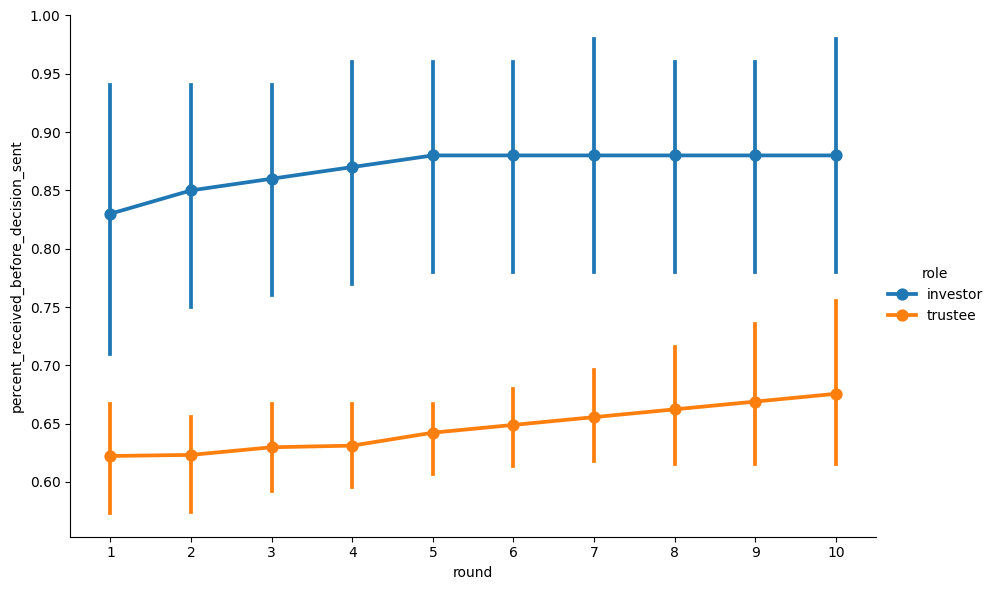

In [27]:
import seaborn as sn
import matplotlib.pyplot as plt

sn.catplot(
    data=df_game_details_aligned,
    x="round",
    y="percent_received_before_decision_sent",
    hue="role",
    kind="point",
    height=6,
    aspect=1.5
)

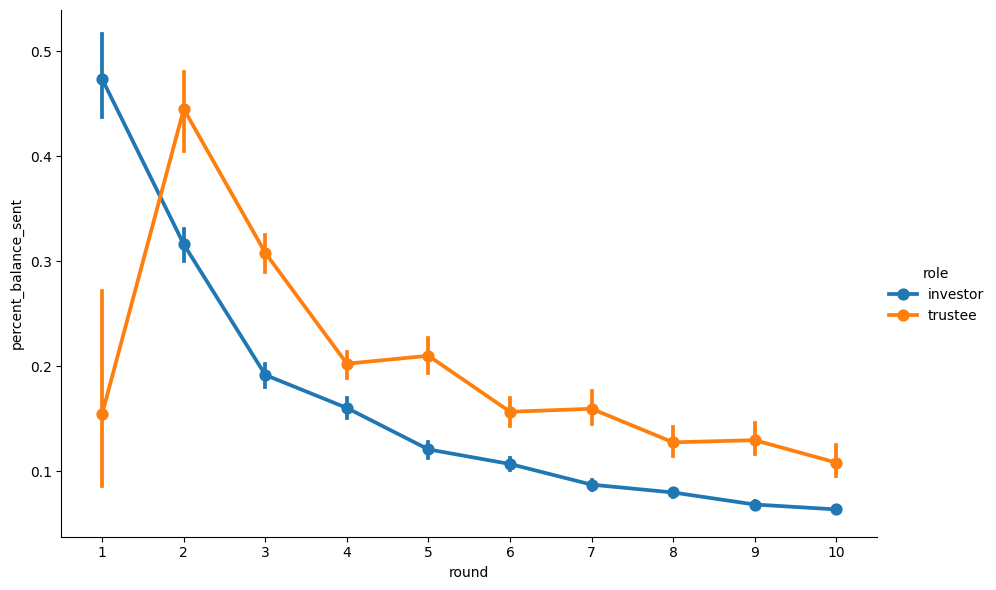

In [28]:
sn.catplot(
    data=df_game_details_aligned,
    x="round",
    y="percent_balance_sent",
    hue="role",
    kind="point",
    height=6,
    aspect=1.5
)

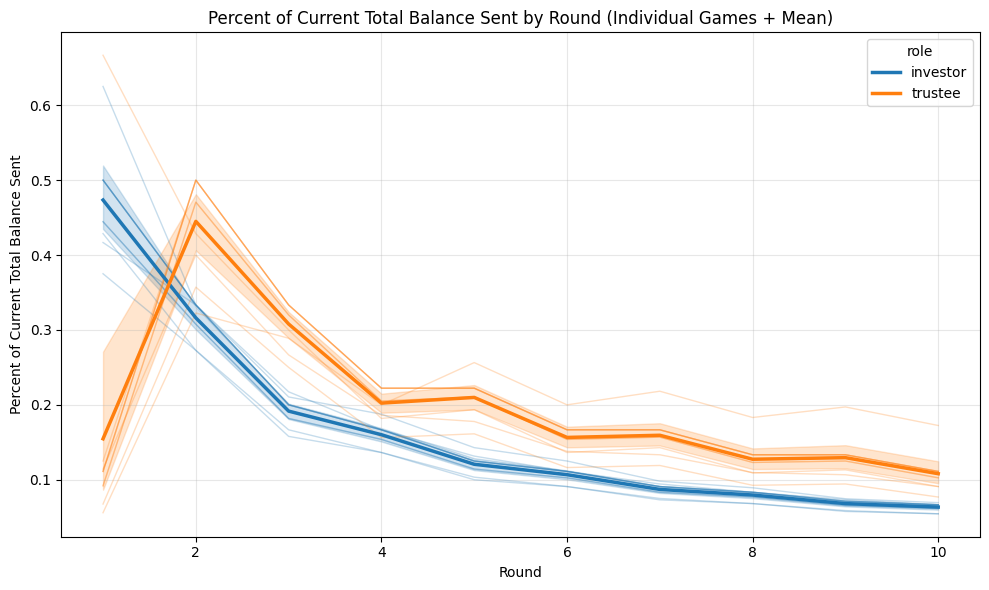

In [29]:
# Same metric as above ("percent_balance_sent"), but include one line per game (run_id)
plot_df = df_game_details_aligned.copy()

plt.figure(figsize=(10, 6))

# Individual game trajectories (thin lines)
sn.lineplot(
    data=plot_df,
    x="round",
    y="percent_balance_sent",
    hue="role",
    units="run_id",
    estimator=None,
    alpha=0.25,
    linewidth=1,
    legend=False
)

# Mean trajectory by role (thick lines)
sn.lineplot(
    data=plot_df,
    x="round",
    y="percent_balance_sent",
    hue="role",
    estimator="mean",
    errorbar=("ci", 95),
    linewidth=2.5
)

plt.title("Percent of Current Total Balance Sent by Round (Individual Games + Mean)")
plt.xlabel("Round")
plt.ylabel("Percent of Current Total Balance Sent")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

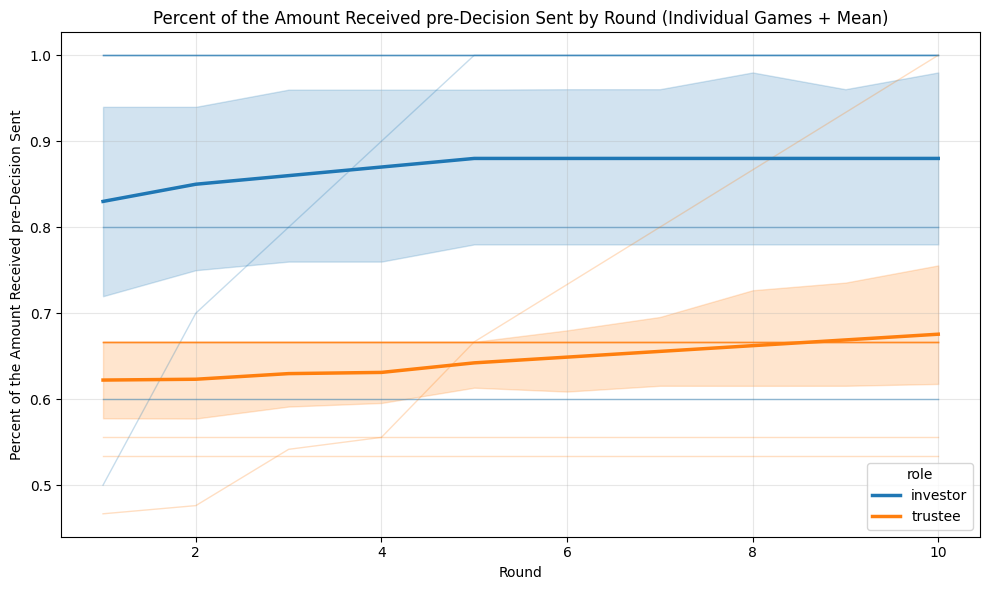

In [30]:
# Same metric as above ("percent_balance_sent"), but include one line per game (run_id)
plot_df = df_game_details_aligned.copy()

plt.figure(figsize=(10, 6))

# Individual game trajectories (thin lines)
sn.lineplot(
    data=plot_df,
    x="round",
    y="percent_received_before_decision_sent",
    hue="role",
    units="run_id",
    estimator=None,
    alpha=0.25,
    linewidth=1,
    legend=False
)

# Mean trajectory by role (thick lines)
sn.lineplot(
    data=plot_df,
    x="round",
    y="percent_received_before_decision_sent",
    hue="role",
    estimator="mean",
    errorbar=("ci", 95),
    linewidth=2.5
)

plt.title("Percent of the Amount Received pre-Decision Sent by Round (Individual Games + Mean)")
plt.xlabel("Round")
plt.ylabel("Percent of the Amount Received pre-Decision Sent")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Analyse similarity of myth morals

In [13]:
game_details_path = '../../data/tables/game_rounds.csv'
df_games = pd.read_csv(game_details_path)

In [ ]:
# Extract a moral for the first 100 myths and save to a new CSV file
myth_path = '../../data/tables/myths.csv'
df_myths = pd.read_csv(myth_path)

# drop any rows that are not in the runs of interest
df_myths = df_myths[df_myths['run_id'].isin(runs_of_interest)]
print(len(df_myths))
myths_of_interest = df_myths['myth_text'].tolist()

# first_100_myths = df_myths.head(100)['myth_text'].tolist()
morals = judge_summary.evaluate_many(myths_of_interest, batch_size=20, max_workers=10)

In [ ]:
moral_summaries = []
for i in range(len(morals)):
    try:
        moral_summary = morals[i].judgment['moral_summary']
        moral_summaries.append(moral_summary)
    except KeyError:
        print(morals[i])
        moral_summaries.append(None)

df_myths['moral_summary'] = moral_summaries

df_myths['key'] = df_myths['run_id'] + '_' + df_myths['round'].astype(str) + '_' + df_myths['agent_id']

df_myths.to_csv('../../data/tables/myths_with_moral_summaries_GLM-5.2.csv', index=False)

In [31]:
df_myths = pd.read_csv('../../data/tables/myths_with_moral_summaries_GLM-5.2.csv')

# merge df_myths with df_game_details_aligned on the 'key' column
# this table is made in the section below! th
df_myths_details_aligned = pd.merge(df_game_details_aligned, df_myths, on=['run_id', 'round', 'agent_id'], how='right')

In [32]:
df_myths_details_aligned

,run_id,round,agent_id,received,sent-returned,balance,prior_balance,role,payoff,final_balance,...,condition_group,condition,model,replicate_id,num_agents,myth_text,n_chars,n_words,source_json,moral_summary
0,sonnet45_directive_normative_r10_n5_005_neutra...,1,Agent_1,NaN,3.0,8.0,5.0,investor,8.0,8.0,...,2agent_clean_sonnet45,myth_game_directive,anthropic/claude-sonnet-4.5,0,2,# The Myth of the Spring and the River\n\nIn t...,1255,208,data/json/sonnet45_directive_normative_r10_n5/...,Generosity and reciprocity create abundance fo...
1,sonnet45_directive_normative_r10_n5_005_neutra...,1,Agent_2,9.0,6.0,3.0,0.0,trustee,3.0,3.0,...,2agent_clean_sonnet45,myth_game_directive,anthropic/claude-sonnet-4.5,0,2,# The Tale of the Twin Rivers\n\nIn ancient ti...,1180,200,data/json/sonnet45_directive_normative_r10_n5/...,Generosity and reciprocity multiply prosperity...
2,sonnet45_directive_normative_r10_n5_005_neutra...,2,Agent_2,NaN,3.0,11.0,0.0,investor,8.0,11.0,...,2agent_clean_sonnet45,myth_game_directive,anthropic/claude-sonnet-4.5,0,2,"Myth: In the time before memory, the Sun and t...",1244,203,data/json/sonnet45_directive_normative_r10_n5/...,NaN
3,sonnet45_directive_normative_r10_n5_005_neutra...,2,Agent_1,9.0,6.0,11.0,5.0,trustee,3.0,11.0,...,2agent_clean_sonnet45,myth_game_directive,anthropic/claude-sonnet-4.5,0,2,"Myth: In the time before time, the Moon held a...",1247,205,data/json/sonnet45_directive_normative_r10_n5/...,Generosity and reciprocity create abundance fo...
4,sonnet45_directive_normative_r10_n5_005_neutra...,3,Agent_1,NaN,3.0,19.0,16.0,investor,8.0,19.0,...,2agent_clean_sonnet45,myth_game_directive,anthropic/claude-sonnet-4.5,0,2,"Myth: Long ago, two Mountains stood across a g...",1373,218,data/json/sonnet45_directive_normative_r10_n5/...,Consistent reciprocity builds trust and mutual...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,sonnet45_directive_normative_r10_n5_014_neutra...,8,Agent_1,15.0,13.0,53.0,56.0,trustee,2.0,53.0,...,2agent_clean_sonnet45,myth_game_normative,anthropic/claude-sonnet-4.5,4,2,Myth: The Spring of Deepening Trust had flowed...,1381,218,data/json/sonnet45_directive_normative_r10_n5/...,Sustained mutual generosity and consistent tru...
196,sonnet45_directive_normative_r10_n5_014_neutra...,9,Agent_1,NaN,5.0,67.0,58.0,investor,14.0,67.0,...,2agent_clean_sonnet45,myth_game_normative,anthropic/claude-sonnet-4.5,4,2,Myth: The Spring of Deepening Trust flowed int...,1349,200,data/json/sonnet45_directive_normative_r10_n5/...,Consistent mutual generosity that escalates ov...
197,sonnet45_directive_normative_r10_n5_014_neutra...,9,Agent_2,15.0,14.0,57.0,56.0,trustee,1.0,57.0,...,2agent_clean_sonnet45,myth_game_normative,anthropic/claude-sonnet-4.5,4,2,Myth: The Mountain of Multiplying Fortunes ent...,1374,217,data/json/sonnet45_directive_normative_r10_n5/...,Consistent generosity between partners creates...
198,sonnet45_directive_normative_r10_n5_014_neutra...,10,Agent_2,NaN,5.0,72.0,57.0,investor,15.0,72.0,...,2agent_clean_sonnet45,myth_game_normative,anthropic/claude-sonnet-4.5,4,2,Myth: The Mountain of Multiplying Fortunes ent...,1372,208,data/json/sonnet45_directive_normative_r10_n5/...,Consistent generosity and escalating reciproci...


In [ ]:
# df_myths_details_aligned.to_csv('../../data/tables/myths_with_moral_summaries_and_game_details_GLM-5.2.csv', index=False)

In [34]:
# Load an SentenceTransformer model for semantic similarity


from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

moral_summaries = df_myths_details_aligned['moral_summary'].tolist()

# Embedding the first 100 myth morals
morals_embeddings = model.encode(moral_summaries)

df_myths['moral_summary_embedding'] = morals_embeddings.tolist()

In [41]:
df_myths_details_aligned['moral_summary_embedding'] = morals_embeddings.tolist()

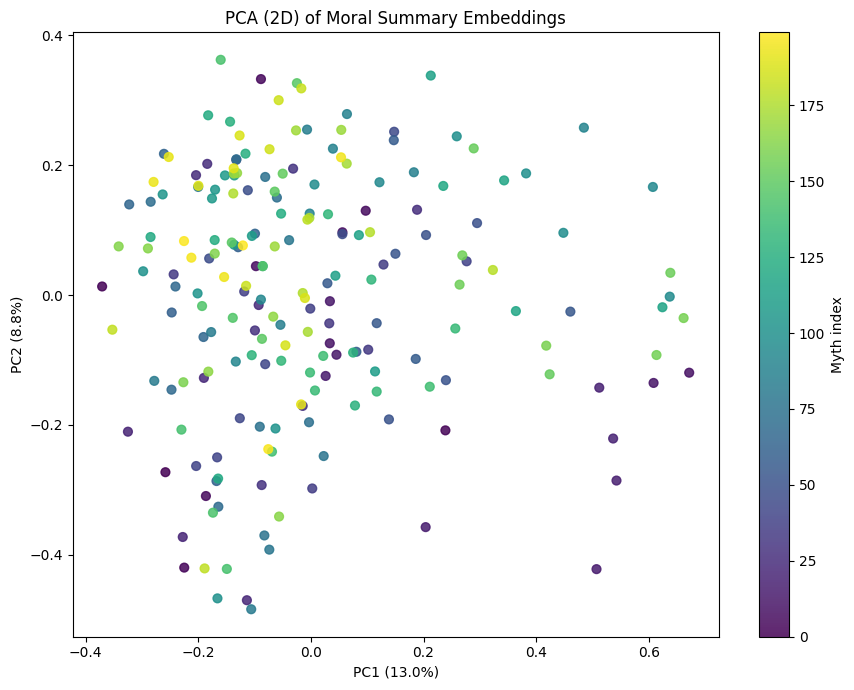

In [35]:
# Reduce embeddings to 3 dimensions with PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(morals_embeddings)

# 2D scatter plot
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111)

points = ax.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=range(len(embeddings_2d)),
    cmap='viridis',
    s=40,
    alpha=0.85
)

ax.set_title("PCA (2D) of Moral Summary Embeddings")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

fig.colorbar(points, ax=ax, label="Myth index")
plt.tight_layout()
plt.show()

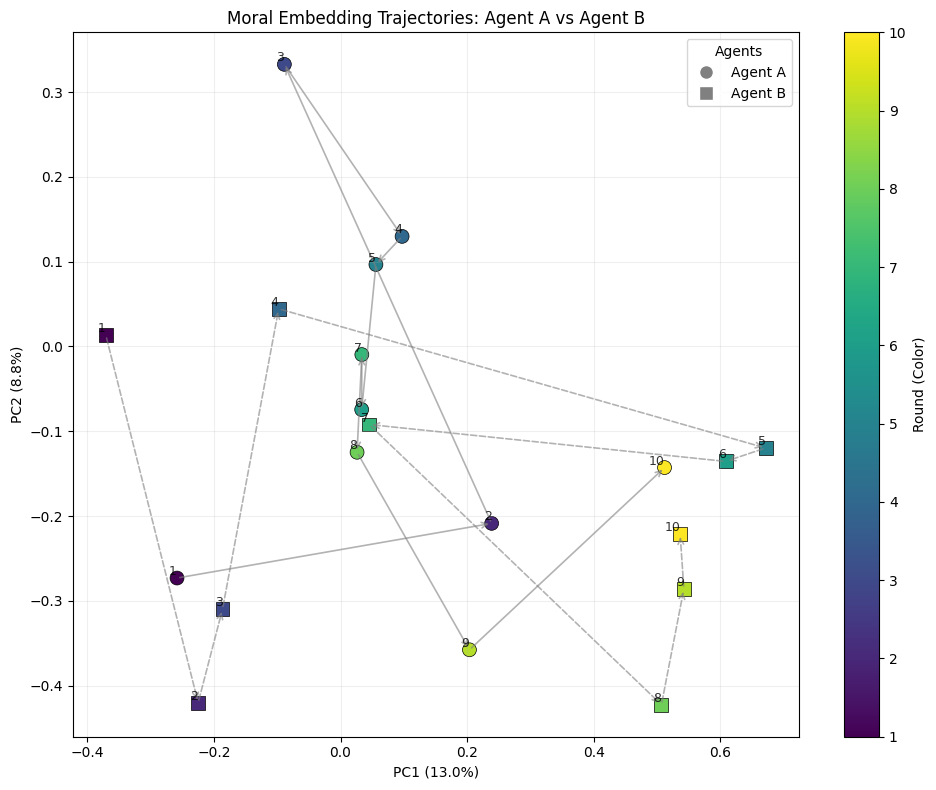

In [36]:
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# Build trajectory data for the first 20 summaries (A, B, A, B, ...)
traj_df = pd.DataFrame(embeddings_2d[:20], columns=["x", "y"])
traj_df["idx"] = range(20)
traj_df["agent"] = traj_df["idx"].map(lambda i: "A" if i % 2 == 0 else "B")
traj_df["round"] = traj_df.groupby("agent").cumcount() + 1  # 1..10 per agent

fig, ax = plt.subplots(figsize=(10, 8))
norm = mcolors.Normalize(vmin=traj_df["round"].min(), vmax=traj_df["round"].max())
cmap = plt.cm.viridis

for agent in ["A", "B"]:
    sub = traj_df[traj_df["agent"] == agent].reset_index(drop=True)
    
    # Custom styles per agent
    ls = "-" if agent == "A" else "--"
    m = "o" if agent == "A" else "s"

    # Draw trajectory with arrows
    for i in range(len(sub) - 1):
        ax.annotate(
            "",
            xy=(sub.loc[i + 1, "x"], sub.loc[i + 1, "y"]),
            xytext=(sub.loc[i, "x"], sub.loc[i, "y"]),
            arrowprops=dict(
                arrowstyle="->", 
                color="gray", 
                lw=1.2, 
                alpha=0.6,
                linestyle=ls
            ),
        )

    # Points colored by round (hue)
    sc = ax.scatter(
        sub["x"], sub["y"],
        c=sub["round"], cmap=cmap, norm=norm,
        s=100, edgecolor="black", linewidth=0.5,
        marker=m, 
        label=f"Agent {agent}"
    )

    # Optional round labels
    for _, r in sub.iterrows():
        ax.text(r["x"], r["y"], str(int(r["round"])), fontsize=9, ha="right", va="bottom", alpha=0.8)

# Create custom legend for markers
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Agent A', markerfacecolor='gray', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Agent B', markerfacecolor='gray', markersize=10)
]
ax.legend(handles=legend_elements, title="Agents")

ax.set_title("Moral Embedding Trajectories: Agent A vs Agent B")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.grid(alpha=0.2)

fig.colorbar(sc, ax=ax, label="Round (Color)")
plt.tight_layout()
plt.show()

,round,cosine_distance
0,1,0.338659
1,2,0.775931
2,3,1.694601
3,4,1.214722
4,5,0.658682
5,6,0.401648
6,7,0.330290
7,8,0.216115
8,9,0.157068
9,10,0.007061


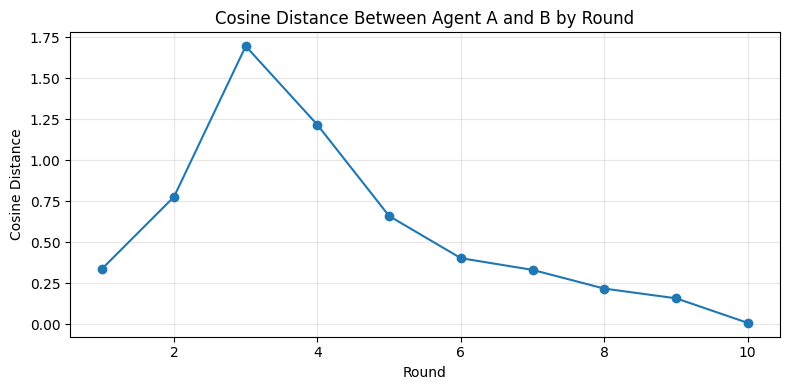

In [37]:
import numpy as np

# Cosine distance per round between Agent A and Agent B (using traj_df: x, y, agent, round)
round_distances = []

for rd in sorted(traj_df["round"].unique()):
    a_vecs = traj_df.loc[(traj_df["round"] == rd) & (traj_df["agent"] == "A"), ["x", "y"]].to_numpy()
    b_vecs = traj_df.loc[(traj_df["round"] == rd) & (traj_df["agent"] == "B"), ["x", "y"]].to_numpy()

    if len(a_vecs) == 0 or len(b_vecs) == 0:
        continue

    # If multiple points exist for a round-agent, use centroid
    a = a_vecs.mean(axis=0)
    b = b_vecs.mean(axis=0)

    cosine_similarity = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
    cosine_distance = 1 - cosine_similarity
    round_distances.append((rd, cosine_distance))

dist_df = pd.DataFrame(round_distances, columns=["round", "cosine_distance"])
display(dist_df)

plt.figure(figsize=(8, 4))
plt.plot(dist_df["round"], dist_df["cosine_distance"], marker="o")
plt.title("Cosine Distance Between Agent A and B by Round")
plt.xlabel("Round")
plt.ylabel("Cosine Distance")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
df_test = df_myths_details_aligned.copy()

,round,mean_distance,ci_low,ci_high,n_games
0,1,0.193633,0.041319,0.403652,5
1,2,0.536866,0.231308,0.932698,5
2,3,0.424976,0.230053,0.619899,5
3,4,0.652495,0.275250,1.200915,5
4,5,0.656508,0.092511,1.231515,5
5,6,1.049293,0.391681,1.706905,5
6,7,1.137020,0.502031,1.772009,5
7,8,0.501218,0.150559,0.851877,5
8,9,0.538277,0.084611,1.220105,5
9,10,0.390982,0.005605,1.157695,5


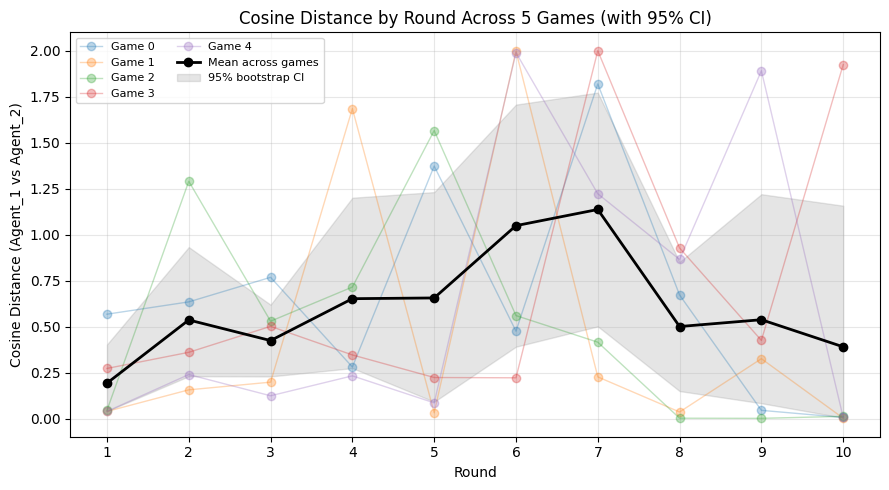

In [44]:
# Align embeddings with df_test metadata
analysis_df = df_test[["replicate_id", "round", "agent_id"]].reset_index(drop=True).copy()
analysis_df["x"] = embeddings_2d[:, 0]
analysis_df["y"] = embeddings_2d[:, 1]

# Cosine distance between Agent_1 and Agent_2 for each game-round
rows = []
for (rep_id, rd), sub_df in analysis_df.groupby(["replicate_id", "round"], sort=True):
    a_vecs = sub_df.loc[sub_df["agent_id"] == "Agent_1", ["x", "y"]].to_numpy()
    b_vecs = sub_df.loc[sub_df["agent_id"] == "Agent_2", ["x", "y"]].to_numpy()
    if len(a_vecs) == 0 or len(b_vecs) == 0:
        continue

    a = a_vecs.mean(axis=0)
    b = b_vecs.mean(axis=0)
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        cosine_distance = np.nan
    else:
        cosine_distance = 1 - (np.dot(a, b) / denom)

    rows.append((rep_id, rd, cosine_distance))

dist_100_df = pd.DataFrame(rows, columns=["replicate_id", "round", "cosine_distance"]).dropna()

# Bootstrap 95% CI for mean distance at each round (across 5 games)
n_boot = 5000
rng = np.random.default_rng(42)

summary_rows = []
for rd, vals in dist_100_df.groupby("round")["cosine_distance"]:
    arr = vals.to_numpy()
    boot_means = np.array([
        rng.choice(arr, size=len(arr), replace=True).mean()
        for _ in range(n_boot)
    ])
    summary_rows.append({
        "round": rd,
        "mean_distance": arr.mean(),
        "ci_low": np.percentile(boot_means, 2.5),
        "ci_high": np.percentile(boot_means, 97.5),
        "n_games": len(arr)
    })

round_ci_df = pd.DataFrame(summary_rows).sort_values("round").reset_index(drop=True)
display(round_ci_df)

# Plot per-game trajectories + round mean with 95% CI band
plt.figure(figsize=(9, 5))

for rep_id, g in dist_100_df.groupby("replicate_id"):
    plt.plot(
        g["round"], g["cosine_distance"],
        marker="o", alpha=0.3, linewidth=1, label=f"Game {rep_id}"
    )

plt.plot(
    round_ci_df["round"], round_ci_df["mean_distance"],
    color="black", marker="o", linewidth=2, label="Mean across games"
)
plt.fill_between(
    round_ci_df["round"],
    round_ci_df["ci_low"],
    round_ci_df["ci_high"],
    color="gray", alpha=0.2, label="95% bootstrap CI"
)

plt.title("Cosine Distance by Round Across 5 Games (with 95% CI)")
plt.xlabel("Round")
plt.ylabel("Cosine Distance (Agent_1 vs Agent_2)")
plt.xticks(range(1, 11))
plt.grid(alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

,replicate_id,agent_id,round,anchor_similarity
0,0,Agent_1,1,1.000000
1,0,Agent_1,1,0.621223
2,0,Agent_1,2,0.750035
3,0,Agent_1,2,0.685000
4,0,Agent_1,3,0.656510
5,0,Agent_1,3,0.753146
6,0,Agent_1,4,0.593870
7,0,Agent_1,4,0.701586
8,0,Agent_1,5,0.612818
9,0,Agent_1,5,0.607581


,round,mean_similarity,ci_low,ci_high,n_series
0,1,0.845615,0.767742,0.918640,20
1,2,0.629557,0.544662,0.698007,20
2,3,0.641348,0.583511,0.695001,20
3,4,0.664166,0.620522,0.706453,20
4,5,0.609054,0.549368,0.661766,20
5,6,0.561493,0.494249,0.622399,20
6,7,0.581151,0.508022,0.648062,20
7,8,0.534229,0.448398,0.615329,20
8,9,0.520437,0.436795,0.598622,20
9,10,0.508697,0.444773,0.572111,20


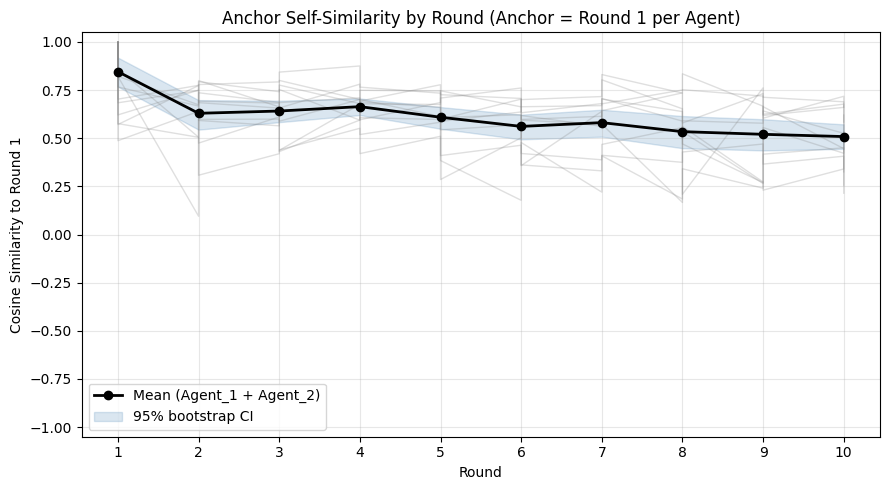

In [45]:
# Anchor self-similarity: round 1 as anchor, compared to later rounds within each (game, agent)

meta_df = df_test[["replicate_id", "round", "agent_id"]].reset_index(drop=True).copy()
meta_df["emb_idx"] = np.arange(len(meta_df))

# Use full sentence embeddings for similarity (better than PCA-reduced coordinates)
emb = morals_embeddings

records = []
for (rep_id, agent_id), grp in meta_df.sort_values("round").groupby(["replicate_id", "agent_id"], sort=True):
    anchor_rows = grp.loc[grp["round"] == 1, "emb_idx"]
    if anchor_rows.empty:
        continue

    anchor_vec = emb[int(anchor_rows.iloc[0])]
    anchor_norm = np.linalg.norm(anchor_vec)

    for _, row in grp.iterrows():
        vec = emb[int(row["emb_idx"])]
        denom = anchor_norm * np.linalg.norm(vec)
        sim = np.nan if denom == 0 else float(np.dot(anchor_vec, vec) / denom)

        records.append(
            (rep_id, agent_id, int(row["round"]), sim)
        )

anchor_sim_df = pd.DataFrame(records, columns=["replicate_id", "agent_id", "round", "anchor_similarity"]).dropna()
display(anchor_sim_df.head(12))

# Aggregate across Agent_1 and Agent_2 (and across games), with bootstrap 95% CI by round
n_boot = 5000
rng_ss = np.random.default_rng(42)

summary_rows = []
for rd, vals in anchor_sim_df.groupby("round")["anchor_similarity"]:
    arr = vals.to_numpy()
    boot_means = np.array([
        rng_ss.choice(arr, size=len(arr), replace=True).mean()
        for _ in range(n_boot)
    ])
    summary_rows.append({
        "round": rd,
        "mean_similarity": arr.mean(),
        "ci_low": np.percentile(boot_means, 2.5),
        "ci_high": np.percentile(boot_means, 97.5),
        "n_series": len(arr)  # 5 games × 2 agents = 10 at each round
    })

anchor_round_ci_df = pd.DataFrame(summary_rows).sort_values("round").reset_index(drop=True)
display(anchor_round_ci_df)

# Plot
plt.figure(figsize=(9, 5))

# optional faint lines for each game-agent trajectory
for (rep_id, agent_id), gsub in anchor_sim_df.groupby(["replicate_id", "agent_id"]):
    plt.plot(
        gsub["round"], gsub["anchor_similarity"],
        color="gray", alpha=0.25, linewidth=1
    )

plt.plot(
    anchor_round_ci_df["round"], anchor_round_ci_df["mean_similarity"],
    color="black", marker="o", linewidth=2, label="Mean (Agent_1 + Agent_2)"
)
plt.fill_between(
    anchor_round_ci_df["round"],
    anchor_round_ci_df["ci_low"],
    anchor_round_ci_df["ci_high"],
    color="steelblue", alpha=0.2, label="95% bootstrap CI"
)

plt.title("Anchor Self-Similarity by Round (Anchor = Round 1 per Agent)")
plt.xlabel("Round")
plt.ylabel("Cosine Similarity to Round 1")
plt.xticks(range(1, 11))
plt.ylim(-1.05, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

,replicate_id,agent_id,prev_round,round,prev_similarity
0,0,Agent_1,1,1,0.621223
1,0,Agent_1,1,2,0.633900
2,0,Agent_1,2,2,0.760268
3,0,Agent_1,2,3,0.728569
4,0,Agent_1,3,3,0.860458
5,0,Agent_1,3,4,0.778904
6,0,Agent_1,4,4,0.786651
7,0,Agent_1,4,5,0.784962
8,0,Agent_1,5,5,0.695039
9,0,Agent_1,5,6,0.686490


,round,mean_similarity,ci_low,ci_high,n_series
0,1,0.691231,0.617281,0.763128,10
1,2,0.609902,0.514990,0.693747,20
2,3,0.690315,0.643597,0.736062,20
3,4,0.744949,0.706887,0.782329,20
4,5,0.673083,0.627724,0.719421,20
5,6,0.647087,0.579637,0.711982,20
6,7,0.593293,0.528042,0.655541,20
7,8,0.585597,0.499446,0.667165,20
8,9,0.547909,0.466796,0.623621,20
9,10,0.575386,0.522142,0.627785,20


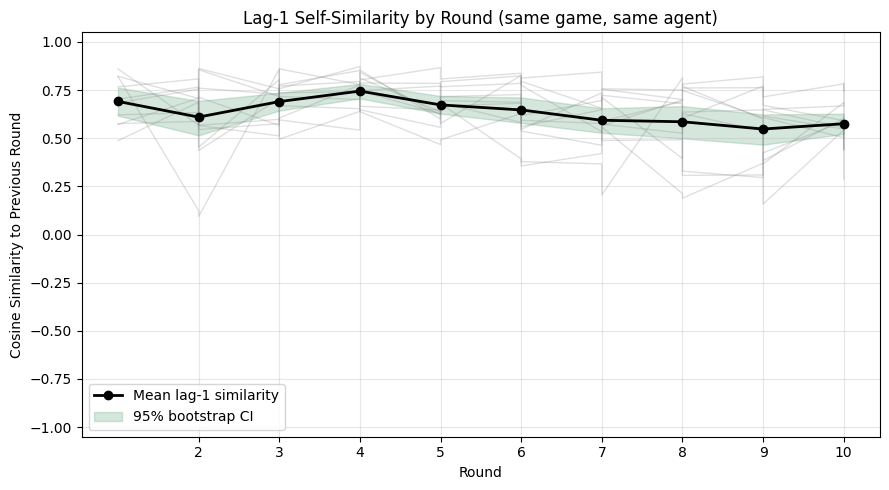

In [46]:
# Similarity to the previous summary by the same agent in the same game (lag-1 similarity)

emb = morals_embeddings  # full embedding space

prev_records = []
for (rep_id, agent_id), grp in meta_df.sort_values("round").groupby(["replicate_id", "agent_id"], sort=True):
    grp = grp.sort_values("round").reset_index(drop=True)
    for i in range(1, len(grp)):
        prev_row = grp.loc[i - 1]
        curr_row = grp.loc[i]

        v_prev = emb[int(prev_row["emb_idx"])]
        v_curr = emb[int(curr_row["emb_idx"])]

        denom = np.linalg.norm(v_prev) * np.linalg.norm(v_curr)
        sim = np.nan if denom == 0 else float(np.dot(v_prev, v_curr) / denom)

        prev_records.append(
            (
                int(rep_id),
                agent_id,
                int(prev_row["round"]),
                int(curr_row["round"]),
                sim
            )
        )

prev_sim_df = pd.DataFrame(
    prev_records,
    columns=["replicate_id", "agent_id", "prev_round", "round", "prev_similarity"]
).dropna()

display(prev_sim_df.head(12))

# Bootstrap CI for mean lag-1 similarity by current round (2..10)
rng_prev = np.random.default_rng(42)
summary_rows = []
for rd, vals in prev_sim_df.groupby("round")["prev_similarity"]:
    arr = vals.to_numpy()
    boot_means = np.array([
        rng_prev.choice(arr, size=len(arr), replace=True).mean()
        for _ in range(n_boot)
    ])
    summary_rows.append({
        "round": rd,
        "mean_similarity": arr.mean(),
        "ci_low": np.percentile(boot_means, 2.5),
        "ci_high": np.percentile(boot_means, 97.5),
        "n_series": len(arr)  # 5 games × 2 agents = 10 per round
    })

prev_round_ci_df = pd.DataFrame(summary_rows).sort_values("round").reset_index(drop=True)
display(prev_round_ci_df)

# Plot trajectories + mean with 95% CI
plt.figure(figsize=(9, 5))

for (rep_id, agent_id), gsub in prev_sim_df.groupby(["replicate_id", "agent_id"]):
    plt.plot(gsub["round"], gsub["prev_similarity"], color="gray", alpha=0.25, linewidth=1)

plt.plot(
    prev_round_ci_df["round"], prev_round_ci_df["mean_similarity"],
    color="black", marker="o", linewidth=2, label="Mean lag-1 similarity"
)
plt.fill_between(
    prev_round_ci_df["round"],
    prev_round_ci_df["ci_low"],
    prev_round_ci_df["ci_high"],
    color="seagreen", alpha=0.2, label="95% bootstrap CI"
)

plt.title("Lag-1 Self-Similarity by Round (same game, same agent)")
plt.xlabel("Round")
plt.ylabel("Cosine Similarity to Previous Round")
plt.xticks(range(2, 11))
plt.ylim(-1.05, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

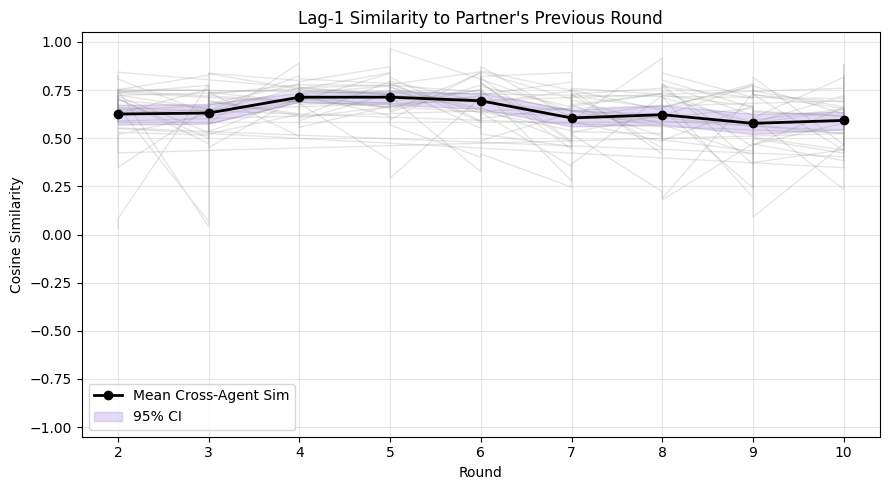

In [47]:
# 1. Pre-normalize embeddings for simple dot-product similarity (vectorized)
norms = np.linalg.norm(morals_embeddings, axis=1, keepdims=True)
norms[norms == 0] = 1 
normed_emb = morals_embeddings / norms

# 2. Align "Other Agent's Previous Round" using a self-merge
# Shift round forward to align (Round i) with (Round i-1), and swap agent IDs
df_ref = meta_df[['replicate_id', 'round', 'agent_id', 'emb_idx']].copy()
df_ref['round'] += 1 

# Map Agent_1 <-> Agent_2
agents = sorted(meta_df["agent_id"].unique())
swap = {agents[0]: agents[1], agents[1]: agents[0]}
df_ref['agent_id'] = df_ref['agent_id'].map(swap)

# Merge back: Each row now contains current idx and the partner's previous idx
cross_prev_df = meta_df.merge(
    df_ref, on=['replicate_id', 'round', 'agent_id'], suffixes=('', '_prev_other')
)

# 3. Calculate similarity vectorized
idx_curr = cross_prev_df['emb_idx'].values
idx_prev = cross_prev_df['emb_idx_prev_other'].values
cross_prev_df['cross_prev_similarity'] = np.sum(normed_emb[idx_curr] * normed_emb[idx_prev], axis=1)

# 4. Bootstrap CI by round
n_boot = 5000
rng = np.random.default_rng(42)

def get_stats(series):
    arr = series.to_numpy()
    boot_means = np.array([rng.choice(arr, size=len(arr), replace=True).mean() for _ in range(n_boot)])
    return pd.Series({
        'mean': arr.mean(),
        'low': np.percentile(boot_means, 2.5),
        'high': np.percentile(boot_means, 97.5)
    })

cross_stats = cross_prev_df.groupby("round")["cross_prev_similarity"].apply(get_stats).unstack().reset_index()

# 5. Plot
plt.figure(figsize=(9, 5))

# Individual traces
for (rep_id, agent_id), gsub in cross_prev_df.groupby(["replicate_id", "agent_id"]):
    plt.plot(gsub["round"], gsub["cross_prev_similarity"], color="gray", alpha=0.2, linewidth=1)

plt.plot(cross_stats["round"], cross_stats["mean"], color="black", marker="o", linewidth=2, label="Mean Cross-Agent Sim")
plt.fill_between(cross_stats["round"], cross_stats["low"], cross_stats["high"], color="mediumpurple", alpha=0.25, label="95% CI")

plt.title("Lag-1 Similarity to Partner's Previous Round")
plt.xlabel("Round")
plt.ylabel("Cosine Similarity")
plt.xticks(range(2, 11))
plt.ylim(-1.05, 1.05); plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

# judge morals of myths

Multiple categories and definitions of morals were considered, we identified that too much granularity makes it very hard to judge even for humans the morals of the myths. the below are some iterations of the schemas tried

#### original categories
1. Maximal cooperation
2. Moderate cooperation
3. Matched reciprocity
4. Trust earned gradually 
5. Forgiveness after betrayal
6. No cooperation after betrayal
7. No cooperation


#### adapted categories
1. Unconditional generosity
2. Matched reciprocity
4. Trust earned gradually 
6. No cooperation after betrayal
7. No cooperation

#### Final categories
1. Be Generous (unconditional cooperativity)
2. Be Fair (matched reciprocity)
3. Be Cautious (trust gradually, or if partner behaves negatively withdraw)


In [8]:
rubric_path = '../../data/rubrics/moral_rubric.txt'
with open(rubric_path, 'r') as file:
    rubric = file.read()

judge = LLMJudge(
    prompt = rubric
    # ,model="openai/gpt-oss-20b"
    ,model="zai-org/GLM-5.2"
)

In [ ]:
# uncomment to run the evaluation and save results to a new CSV file

# myths_path = '../../data/tables/myths.csv'
# df = pd.read_csv(myths_path)
# df = df.head(10)
# myth_texts = df['myth_text'].tolist()
# judgements = judge.evaluate_many(myth_texts, batch_size=10, max_workers=10)
# m = judge.model
# m = m.split('/')[-1]
# new_col_name = f'judgement_{m}'
# df[new_col_name] = judgements
# df.to_csv(f'../../data/tables/myths_with_judgements_{m}.csv', index=False)

In [12]:
m = judge.model
m = m.split('/')[-1]

df = pd.read_csv(f'../../data/tables/myths_with_judgements_{m}.csv')
for i, row in df.iterrows():
    print(row[f'judgement_{m}'])

index=0 raw_response='{"label": "Maximal cooperation"}' judgment={'label': 'Maximal cooperation'} parse_status='ok' parse_error=None model='zai-org/GLM-5.2' usage={'completion_tokens': 9, 'prompt_tokens': 1625, 'total_tokens': 1634, 'prompt_tokens_details': {'cached_tokens': 0}}
index=1 raw_response='{"label": "Maximal cooperation"}' judgment={'label': 'Maximal cooperation'} parse_status='ok' parse_error=None model='zai-org/GLM-5.2' usage={'completion_tokens': 9, 'prompt_tokens': 1606, 'total_tokens': 1615, 'prompt_tokens_details': {'cached_tokens': 0}}
index=2 raw_response='{"label":"Moderate cooperation"}' judgment={'label': 'Moderate cooperation'} parse_status='ok' parse_error=None model='zai-org/GLM-5.2' usage={'completion_tokens': 8, 'prompt_tokens': 1616, 'total_tokens': 1624, 'prompt_tokens_details': {'cached_tokens': 1344}}
index=3 raw_response='{"label": "Maximal cooperation"}' judgment={'label': 'Maximal cooperation'} parse_status='ok' parse_error=None model='zai-org/GLM-5.2'

### Classify Myths into 3 moral categories

simpler rubric than above: we want to understand if the moral promotes unconditional vs conditional behaviour and what direction it has.

1. Be Generous (unconditional cooperativity)
2. Be Fair (matched reciprocity)
3. Be Cautious (trust gradually, or if partner behaves negatively withdraw)

In [49]:
rubric_path = '../../data/rubrics/3moral_rubric.txt'
with open(rubric_path, 'r') as file:
    rubric = file.read()

judge_3moral = LLMJudge(
    prompt = rubric
    ,model="zai-org/GLM-5.2"
)

In [50]:
# wee test
myth = df_myths_details_aligned['myth_text'][0]
judgement = judge_3moral.evaluate(myth)
judgement

JudgeResult(index=0, raw_response='{"label":"be generous"}', judgment={'label': 'be generous'}, parse_status='ok', parse_error=None, model='zai-org/GLM-5.2', usage={'completion_tokens': 7, 'prompt_tokens': 2294, 'total_tokens': 2301, 'prompt_tokens_details': {'cached_tokens': 0}})

In [53]:
m = judge_3moral.model
m = m.split('/')[-1]

In [ ]:
# uncomment to run the evaluation and save results to a new CSV file

# myth_texts = df_myths_details_aligned['myth_text'].tolist()
# judgements = judge_3moral.evaluate_many(myth_texts, batch_size=10, max_workers=10)

# labels = [j.judgment['label'] for j in judgements]
# new_col_name = f'judgement_{m}'
# df_myths_details_aligned[new_col_name] = labels
# df_myths_details_aligned.to_csv(f'../../data/tables/myths_with_judgements_{m}.csv', index=False)

In [72]:
df_myths_with_judgements = pd.read_csv(f'../../data/tables/myths_gameplay_with_judgements_{m}.csv')

In [73]:
print(list(df_myths_with_judgements.columns))

['run_id', 'round', 'agent_id', 'received', 'sent-returned', 'balance', 'prior_balance', 'role', 'payoff', 'final_balance', 'decision_balance', 'received_before_decision', 'percent_balance_sent', 'percent_received_before_decision_sent', 'percent_delta_balance', 'percent_delta_received', 'condition_group', 'condition', 'model', 'replicate_id', 'num_agents', 'myth_text', 'n_chars', 'n_words', 'source_json', 'moral_summary', 'moral_summary_embedding', 'key', 'judgement_GLM-5.2', 'moral_rating', 'moral_rating_delta']


In [74]:
# df_myths_details_aligned['judgement_GLM-5.2'].value_counts()

In [ ]:
# df_myths_details_aligned = pd.merge(df_game_details_aligned, df_myths_with_judgements, on=['run_id', 'round', 'agent_id'], how='right')

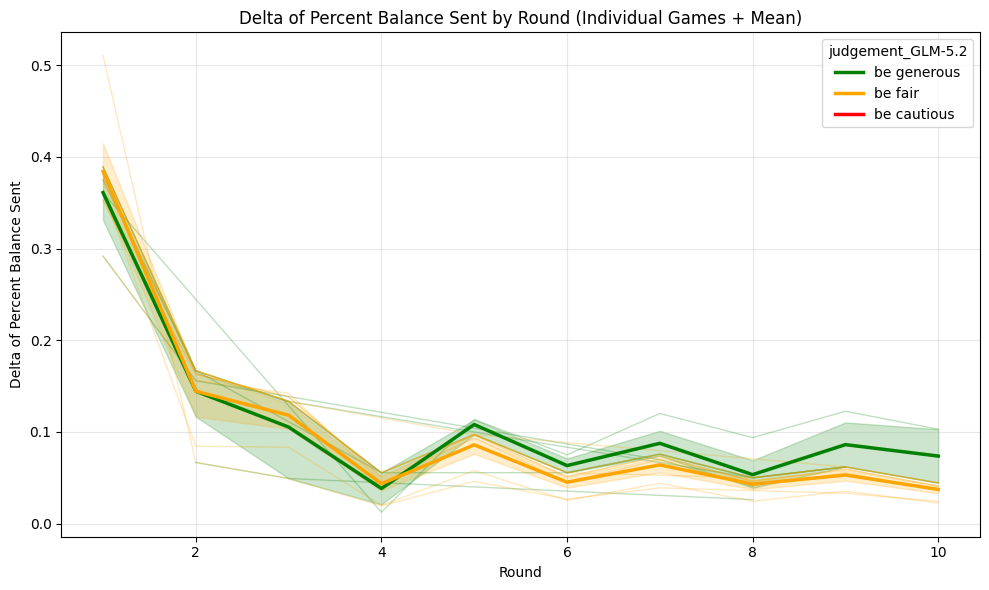

In [77]:
# Same metric as above ("percent_balance_sent"), but include one line per game (run_id)
# plot_df = df_myths_details_aligned.copy()
plot_df = df_myths_with_judgements.copy()

plt.figure(figsize=(10, 6))

# Colors for the judgement labels
judgement_palette = {
    "be generous": "green",
    "be fair": "orange",
    "be cautious": "red",
}

# Individual game trajectories (thin lines)
sn.lineplot(
    data=plot_df,
    x="round",
    y="percent_delta_balance",
    hue="judgement_GLM-5.2",
    units="run_id",
    palette=judgement_palette,
    estimator=None,
    alpha=0.25,
    linewidth=1,
    legend=False
)

# Mean trajectory by role (thick lines)
sn.lineplot(
    data=plot_df,
    x="round",
    y="percent_delta_balance",
    hue="judgement_GLM-5.2",
    palette=judgement_palette,
    estimator="mean",
    errorbar=("ci", 95),
    linewidth=2.5
)

plt.title("Delta of Percent Balance Sent by Round (Individual Games + Mean)")
plt.xlabel("Round")
plt.ylabel("Delta of Percent Balance Sent")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

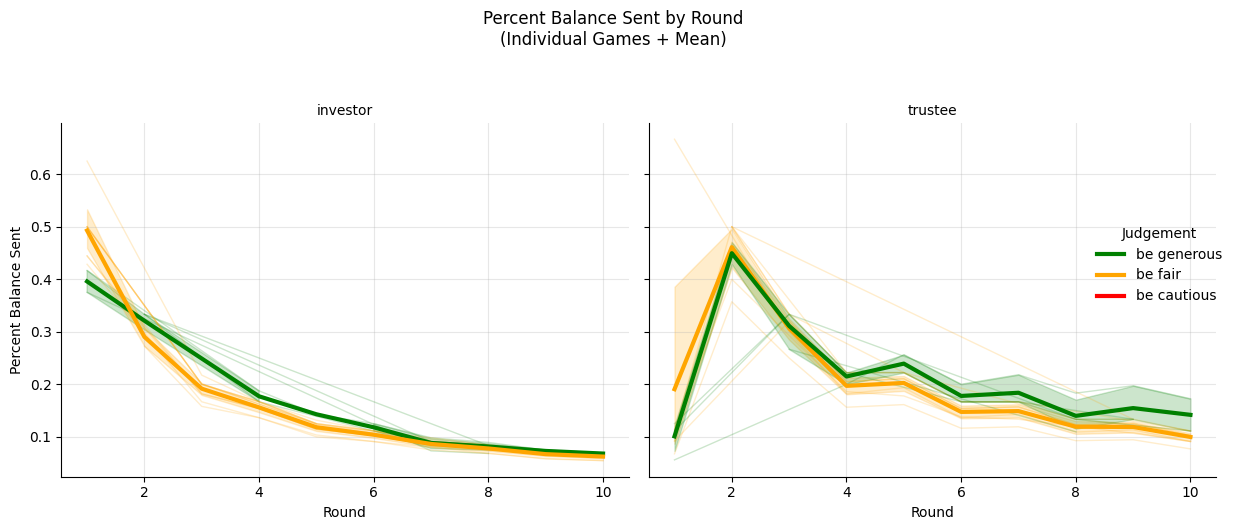

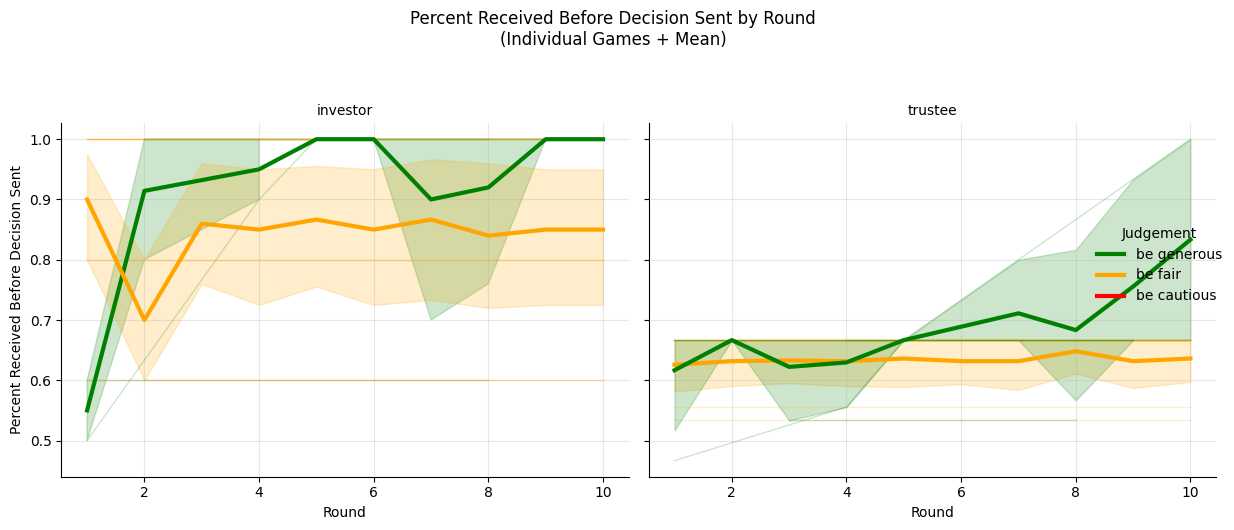

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = df_myths_with_judgements.copy()

# Colors for the judgement labels
judgement_palette = {
    "be generous": "green",
    "be fair": "orange",
    "be cautious": "red",
}

for y_variable in ["percent_balance_sent", "percent_received_before_decision_sent"]:

    g = sns.FacetGrid(
        plot_df,
        col="role",
        height=5,
        aspect=1.1,
        sharey=True
    )

    # Individual game trajectories
    g.map_dataframe(
        sns.lineplot,
        x="round",
        y=y_variable,
        hue="judgement_GLM-5.2",
        units="run_id",
        estimator=None,
        palette=judgement_palette,
        alpha=0.2,
        linewidth=1,
        legend=False,
    )

    # Mean trajectories with 95% CI
    g.map_dataframe(
        sns.lineplot,
        x="round",
        y=y_variable,
        hue="judgement_GLM-5.2",
        palette=judgement_palette,
        estimator="mean",
        errorbar=("ci", 95),
        linewidth=3,
    )

    g.add_legend(title="Judgement")
    g.set_axis_labels(
        "Round",
        y_variable.replace("_", " ").title()
    )
    g.set_titles("{col_name}")

    for ax in g.axes.flat:
        ax.grid(alpha=0.3)

    g.figure.suptitle(
        f"{y_variable.replace('_', ' ').title()} by Round\n"
        "(Individual Games + Mean)",
        y=1.05
    )

    plt.tight_layout()
    plt.show()

#### How do morals change over time?

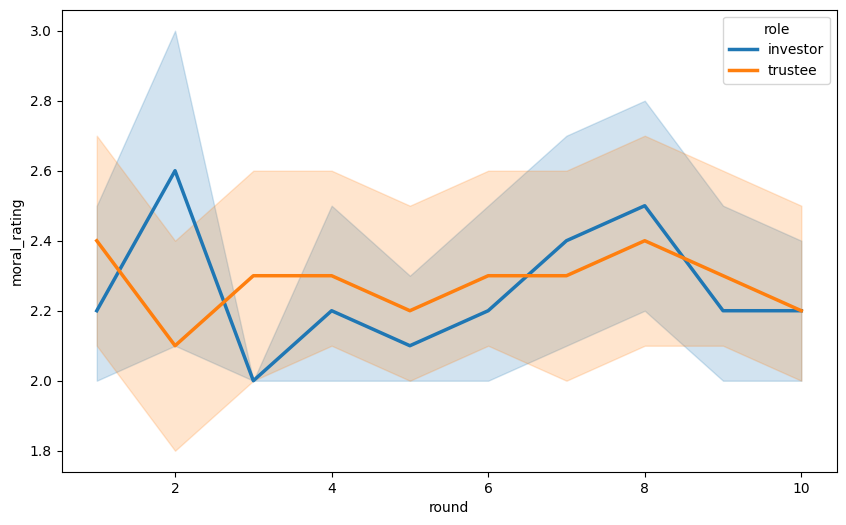

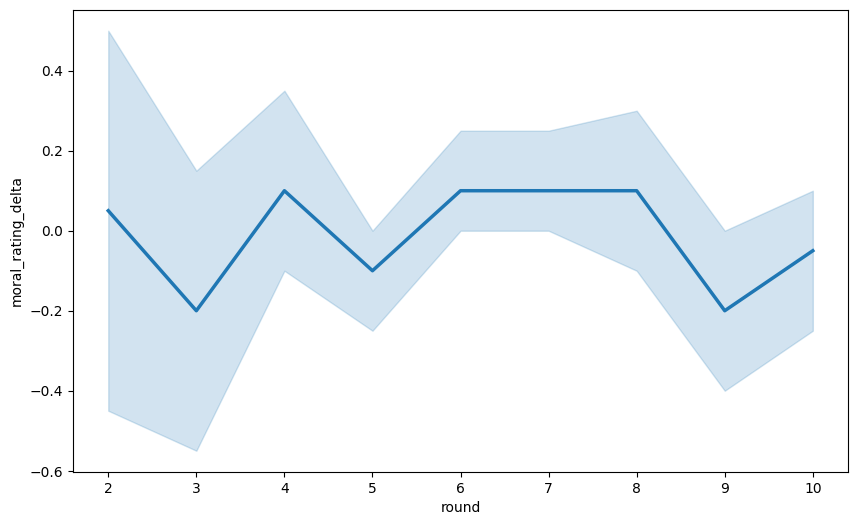

In [83]:
# how to morals change over time
moral_rating = {
    "be generous": 3,
    "be fair": 2,
    "be cautious": 1,
}
df_myths_with_judgements['moral_rating'] = df_myths_with_judgements['judgement_GLM-5.2'].map(moral_rating)
df_myths_with_judgements['moral_rating_delta'] = df_myths_with_judgements.groupby(['run_id', 'role'])['moral_rating'].diff()

#plot moral rating over time (rounds) for each agent, with individual game trajectories (thin lines) and mean trajectory (thick line) with 95% CI
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_myths_with_judgements,
    x="round",
    y="moral_rating",
    hue="role",
    estimator="mean",
    errorbar=("ci", 95),
    linewidth=2.5
)

plt.show()

#plot moral rating over time (rounds) for each agent, with individual game trajectories (thin lines) and mean trajectory (thick line) with 95% CI
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_myths_with_judgements,
    x="round",
    y="moral_rating_delta",
    estimator="mean",
    errorbar=("ci", 95),
    linewidth=2.5
)

plt.show()

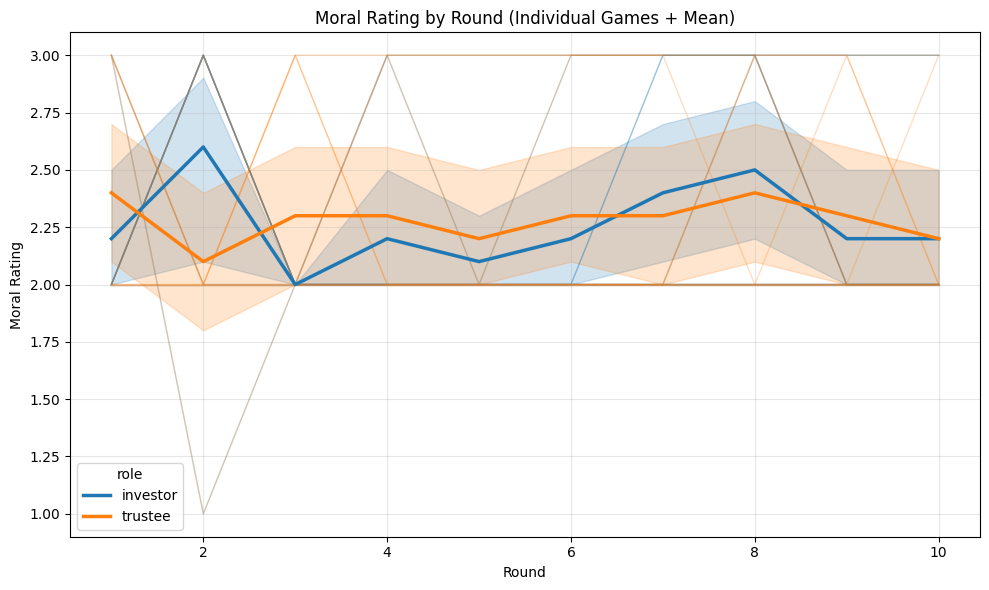

In [84]:
# Same metric as above ("percent_balance_sent"), but include one line per game (run_id)
plot_df = df_myths_with_judgements.copy()

plt.figure(figsize=(10, 6))

# Individual game trajectories (thin lines)
sn.lineplot(
    data=plot_df,
    x="round",
    y="moral_rating",
    hue="role",
    units="run_id",
    estimator=None,
    alpha=0.25,
    linewidth=1,
    legend=False
)

# Mean trajectory by role (thick lines)
sn.lineplot(
    data=plot_df,
    x="round",
    y="moral_rating",
    hue="role",
    estimator="mean",
    errorbar=("ci", 95),
    linewidth=2.5
)

plt.title("Moral Rating by Round (Individual Games + Mean)")
plt.xlabel("Round")
plt.ylabel("Moral Rating")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:

df_manifest = pd.read_csv('../../data/manifest.csv')
print(list(df_manifest.columns))

cols_of_interest = ['run_id','n_game_rows', 'mean_sent', 'mean_returned', 'final_mean_balance', 'final_min_balance', 'final_max_balance','num_turns', 'memory_capacity']

df_manifest[((df_manifest['task_order'] == 'myth->game') & 
             (df_manifest['condition_group'] == '2agent_clean_sonnet45'))][cols_of_interest]

['run_id', 'condition_group', 'condition_label', 'condition', 'original_json_path', 'packaged_json_path', 'packaged_pdf_path', 'original_pdf_path', 'task_order', 'num_rounds_observed', 'n_myths', 'n_game_rows', 'mean_sent', 'mean_returned', 'final_mean_balance', 'final_min_balance', 'final_max_balance', 'agent_names_json', 'prompt_keys_json', 'model', 'temperature', 'num_agents', 'num_turns', 'memory_capacity', 'replicate_id', 'myth_prompt_arm_id', 'myth_topic_id', 'myth_topic', 'history_policy', 'self_history_window', 'coplayer_history_window', 'show_agent_names', 'system_addition_key', 'game_params_name', 'myth_default_prompt_key', 'myth_later_prompt_key']


,run_id,n_game_rows,mean_sent,mean_returned,final_mean_balance,final_min_balance,final_max_balance,num_turns,memory_capacity
5,sonnet45_directive_normative_r10_n5_005_neutra...,10,3.00,6.00,55.0,55.0,55.0,10,3
6,sonnet45_directive_normative_r10_n5_006_neutra...,10,5.00,8.00,75.0,75.0,75.0,10,3
7,sonnet45_directive_normative_r10_n5_007_neutra...,10,5.00,10.00,75.0,75.0,75.0,10,3
8,sonnet45_directive_normative_r10_n5_008_neutra...,10,5.00,10.00,75.0,75.0,75.0,10,3
9,sonnet45_directive_normative_r10_n5_009_neutra...,10,4.00,8.00,65.0,65.0,65.0,10,3
10,sonnet45_directive_normative_r10_n5_010_neutra...,10,5.00,10.00,75.0,75.0,75.0,10,3
11,sonnet45_directive_normative_r10_n5_011_neutra...,10,5.00,10.00,75.0,75.0,75.0,10,3
12,sonnet45_directive_normative_r10_n5_012_neutra...,10,4.00,8.00,65.0,65.0,65.0,10,3
13,sonnet45_directive_normative_r10_n5_013_neutra...,10,3.00,5.00,55.0,55.0,55.0,10,3
14,sonnet45_directive_normative_r10_n5_014_neutra...,10,4.45,9.75,69.5,67.0,72.0,10,3
